In [2]:
# Zachary Katz
# zachary_katz@mines.edu
# 25 March 2026


"""
SWOT Harmonic Analysis over ice shelves

Download selected SWOT data and load for two passes.
Advect based on Measures ice velocity map
Compute harmonic analysis, removing outliers
Calculate difference from CATS and plot.
"""

# Extensions and imports
%load_ext autoreload
%autoreload 2

import util.coordinate_transforms as transforms
import shapefile
import shapely
import earthaccess
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree

from pyproj import CRS, Transformer

import rasterio

import re
from collections import defaultdict
from pathlib import Path
import pyTMD

# Paths
data_dir = "../_data/SWOT"


vel_path = "/mnt/c/users/ZacharyKatz/Desktop/Research/Background/antarctica_ice_velocity_450m_v2.nc"  # Path to velocity field
vel_mag_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/antarctic_ice_vel_phase_map_v01-vmag.nc"  # Path to velocity magnitude
moa_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/moa750_2009_hp1_v1.1.tif"  # Path to MOA
# RINGS Grounding Line Paths
rings_grounded_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp"
rings_coastline_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_coastline_2022.shp"
rings_grounded_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp"
rings_iceshelves_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_iceshelves_2022.shp"
rings_islands_ADD = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_islands_ADD.shp"
rings_polygonmask = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_polygonmask.shp"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Load grounding lines
paths = [
    rings_coastline_path,
    rings_grounded_path,
    rings_iceshelves_path,
    rings_islands_ADD,
    rings_polygonmask,
]

records_full = []
shapes_full = []
field_names_full = []

for path in paths:
    sf = shapefile.Reader(path)
    records_full.append(sf.records())
    shapes_full.append(sf.shapes())
    field_names_full.append([f[0] for f in sf.fields[1:]])

ice_shelf_polygons = []
grounded_polygons = []

sf = shapefile.Reader(rings_iceshelves_path)
fields = sf.fields[1:]  # Skip deletion flag
field_names = [field[0] for field in fields]

records = sf.records()
shapes = sf.shapes()

for record, shape in zip(records, shapes):
    rec_dict = dict(zip(field_names, record))
    classification = rec_dict["Type"]
    points = shape.points
    parts = list(shape.parts)
    parts.append(len(points))  # Append the end index of the last part
    for i in range(len(parts) - 1):
        part = points[parts[i] : parts[i + 1]]
        polygon = shapely.Polygon(part)
        if (
            classification == "Isolated island"
            or classification == "Ice rise or connected island"
            or classification == "Grounded ice or land"
        ):
            if polygon.is_valid:
                grounded_polygons.append(polygon)
        elif classification == "Ice shelf":
            if polygon.is_valid:
                ice_shelf_polygons.append(polygon)
        else:
            print(f"Unknown classification: {classification}")


def plot_RINGS_shapefile(
    records_list: list[shapefile._Record],
    shapes_list: list[shapefile.Shape],
    field_names_list: list[str],
    ax,
    colors: list[str],
    transform,
    fill: bool = False,
    zorder: int = 2,
    linewidth: int = 2,
) -> None:
    """
    Plots the given records and shapes on axis ax.

    Example usage:

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
        transform=ps71_projection, fill=False, zorder=2, linewidth=1)

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for records, shapes, field_names in zip(
        records_list, shapes_list, field_names_list
    ):
        for record, shape in zip(records, shapes):
            rec_dict = dict(zip(field_names, record))
            classification = rec_dict["Type"]
            points = shape.points
            parts = list(shape.parts)
            parts.append(
                len(points)
            )  # Append the end index of the last part of the shapefile
            for i in range(len(parts) - 1):
                part = points[parts[i] : parts[i + 1]]
                if classification == "Coastline":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[1],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[1],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                elif classification == "Grounded":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[0],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[0],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                elif classification == "Transient":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[0],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[0],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                elif classification == "Island":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[0],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[0],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                else:
                    # print(f"Unknown classification: {classification}")
                    continue


with rasterio.open(moa_path) as moa:
    bounds = moa.bounds
    left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
    moa_dat = moa.read(1)

ext = (left, right, bottom, top)

vel_mag = xr.open_dataarray(vel_mag_path)
bbox = [1500000, 590000, 2420000, 850000]  # Amery + some

vel_mag_sliced = vel_mag.sel(x=slice(1300000, 2800000), y=slice(900000, 390000))

velocity = xr.open_dataset(vel_path)
off = 100000
bbox = [1500000, 590000, 2420000, 850000]  # Amery + some
cropped_vel = velocity.sel(
    x=slice(bbox[0] - off, bbox[2] + off), y=slice(bbox[3] + off, bbox[1] - off)
)


def prep_velocity_interpolators(
    vel,
):  # Create interpolators at any point for quick querying
    vx_interp = RegularGridInterpolator(
        (vel.y.values[::-1], vel.x.values),
        vel["VX"].values[::-1, :],
        bounds_error=False,
        fill_value=np.nan,
    )
    vy_interp = RegularGridInterpolator(
        (vel.y.values[::-1], vel.x.values),
        vel["VY"].values[::-1, :],
        bounds_error=False,
        fill_value=np.nan,
    )
    return vx_interp, vy_interp

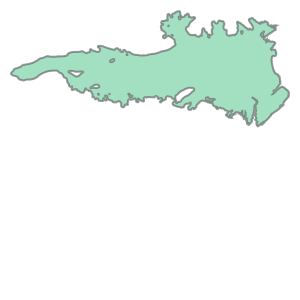

In [4]:
bbox_filter = [2000000, 650000, 2000001, 650001]
filtered_records_main = []
filtered_shapes_main = []
for record, _shape in zip(records, shapes):
    shape_bbox = _shape.bbox
    # Checks if any part of the shape is within the bounding box
    if (
        shape_bbox[0] < bbox_filter[2]
        and shape_bbox[2] > bbox_filter[0]
        and shape_bbox[1] < bbox_filter[3]
        and shape_bbox[3] > bbox_filter[1]
    ):
        filtered_records_main.append(record)
        filtered_shapes_main.append(_shape)
main_shapefile = shapely.geometry.shape(filtered_shapes_main[0].__geo_interface__)

main_shapefile

In [3]:
# Dowload SWOT if necessary
amery_bbox = [1500000, 590000, 2480000, 850000]
amery_xy = [
    (amery_bbox[0], amery_bbox[1]),  # xmin, ymin
    (amery_bbox[2], amery_bbox[1]),  # xmax, ymin
    (amery_bbox[2], amery_bbox[3]),  # xmax, ymax
    (amery_bbox[0], amery_bbox[3]),  # xmin, ymax
]

amery_ll = [transforms.xy2ll(x, y) for x, y in amery_xy]
lons, lats = zip(*amery_ll)
amery_ll_bbox = [min(lons), min(lats), max(lons), max(lats)]
amery_ll_bbox = tuple(v for v in amery_ll_bbox)


for track in ["271", "299", "327", "577"]:
    karin_results = earthaccess.search_data(
        short_name="SWOT_L2_HR_Raster_D",
        temporal=("2020-01-01", "2030-01-01"),
        granule_name=f"*100m*x_*_{track}_0??F*.nc",
        bounding_box=amery_ll_bbox,
    )
    earthaccess.download(karin_results, f"{data_dir}/SWOT_{track}", provider="POCLOUD")

QUEUEING TASKS | :   0%|          | 0/70 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/70 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/70 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/121 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/121 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/33 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/44 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/44 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/44 [00:00<?, ?it/s]

In [47]:
# Load rasters, get latest version, and select specific rasters to keep

rasters = list(Path(data_dir).rglob("SWOT_L2_HR_Raster*PID0_??.nc"))
print(f"Found {len(rasters)} rasters")

latest = defaultdict(lambda: (None, -1))

for f in rasters:
    match = re.search(r"(.*)_PID0_(\d+)\.nc$", f.name)
    if match:
        base, version = match.groups()
        version = int(version)
        if version > latest[base][1]:
            latest[base] = (f, version)

# Collect just the paths
rasters = [val[0] for val in latest.values()]

# Only keep rasters based on track number, etc.
swot_rasters = [f for f in rasters if ("_299_014F" in f.name)]
# Sort by granule number, then cycle number
swot_rasters.sort(
    key=lambda f: (
        re.search(r"_x_(\d+)_", f.name).group(1),
        re.search(r"_0(\d{2})F", f.name).group(1),
    )
)
print(f"Keeping {len(swot_rasters)} rasters")
for raster in swot_rasters:
    print(raster)

Found 224 rasters
Keeping 16 rasters
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_032_299_014F_20250508T162648_20250508T162709_PID0_02.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_033_299_014F_20250529T131155_20250529T131216_PID0_02.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_034_299_014F_20250619T095658_20250619T095719_PID0_01.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_035_299_014F_20250710T064206_20250710T064227_PID0_01.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_036_299_014F_20250731T032710_20250731T032731_PID0_01.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_037_299_014F_20250821T001215_20250821T001236_PID0_01.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_038_299_014F_20250910T205718_20250910T205739_PID0_01.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_039_299_014F_20251001T174222_20251001T174244_PID0_01.nc
../_data/SWOT/SWOT_299/SWOT

In [66]:
# Advect chosen rasters to common reference time using using vel grid
# Reference time is approx mean of raster times based on names, to minimize advection errors

raster_times = []
for r in swot_rasters:
    matches = re.findall(r"(\d{8}T\d{6})", r.name)
    assert len(matches) > 0, f"No timestamp found in raster name: {r.name}"
    match = matches[0]
    raster_time = datetime.strptime(match, "%Y%m%dT%H%M%S")
    raster_times.append(raster_time)

mean_timestamp = sum(dt.timestamp() for dt in raster_times) / len(raster_times)
mean_date = datetime.fromtimestamp(mean_timestamp)

# Advect raster positions x,y to mean_date
vx_interp, vy_interp = prep_velocity_interpolators(cropped_vel)
delta_t = 10  # Days
DAY_TO_YEAR = 365.25
DAY_TO_SECONDS = 24 * 3600
multiplier = delta_t / DAY_TO_YEAR

crs_ps = CRS.from_epsg(3031)
for raster in swot_rasters[:]:
    ds = xr.open_dataset(raster, decode_times=False)
    raster_time = datetime.strptime(ds.time_granule_start, "%Y-%m-%dT%H:%M:%S.%fZ")
    direction = 1 if raster_time < mean_date else -1
    timesteps = int(
        abs((mean_date - raster_time).total_seconds()) // (delta_t * DAY_TO_SECONDS)
    )

    # Get SWOT and velocity grid in PS71
    x = ds.x.values
    y = ds.y.values

    utm = ccrs.UTM(zone=ds.utm_zone_num, southern_hemisphere=True)
    epsg = utm.to_epsg()
    crs_utm = CRS.from_epsg(epsg)

    transformer = Transformer.from_crs(crs_utm, crs_ps, always_xy=True)
    X_utm, Y_utm = np.meshgrid(x, y)
    X, Y = transformer.transform(X_utm, Y_utm)

    ds["x_ps71"] = (("y", "x"), X)
    ds["y_ps71"] = (("y", "x"), Y)

    points = np.empty((X.size, 2), dtype=X.dtype)
    print(points.shape, mean_date, raster_time, direction, timesteps)

    # Advection loop
    for i in range(timesteps):
        points[:, 0] = Y.ravel()
        points[:, 1] = X.ravel()

        vx = vx_interp(points).reshape(X.shape)
        vy = vy_interp(points).reshape(Y.shape)

        X += direction * vx * multiplier
        Y += direction * vy * multiplier

        # print(X)

    ds["x_adv"] = (("y", "x"), X)
    ds["y_adv"] = (("y", "x"), Y)

    # Save new advected raster
    output_raster = raster.with_name(raster.stem + "_adv.nc")
    ds.to_netcdf(output_raster)

(3247204, 2) 2025-10-12 04:27:24.812500 2025-05-08 16:26:48.048791 1 15
(3247204, 2) 2025-10-12 04:27:24.812500 2025-05-29 13:11:55.000836 1 13
(3247204, 2) 2025-10-12 04:27:24.812500 2025-06-19 09:56:58.257160 1 11
(3247204, 2) 2025-10-12 04:27:24.812500 2025-07-10 06:42:06.083477 1 9
(3247204, 2) 2025-10-12 04:27:24.812500 2025-07-31 03:27:10.425528 1 7
(3247204, 2) 2025-10-12 04:27:24.812500 2025-08-21 00:12:15.205378 1 5
(3247204, 2) 2025-10-12 04:27:24.812500 2025-09-10 20:57:18.604322 1 3
(3247204, 2) 2025-10-12 04:27:24.812500 2025-10-01 17:42:22.819877 1 1
(3247204, 2) 2025-10-12 04:27:24.812500 2025-10-22 14:27:28.667084 -1 1
(3247204, 2) 2025-10-12 04:27:24.812500 2025-11-12 11:12:31.805005 -1 3
(3247204, 2) 2025-10-12 04:27:24.812500 2025-12-03 07:57:35.869405 -1 5
(3247204, 2) 2025-10-12 04:27:24.812500 2025-12-24 04:42:40.896280 -1 7
(3247204, 2) 2025-10-12 04:27:24.812500 2026-01-14 01:27:45.342900 -1 9
(3247204, 2) 2025-10-12 04:27:24.812500 2026-02-03 22:12:49.934347 -1

In [67]:
# Load advected rasters, get latest version, and select specific rasters to keep
rasters = list(Path(data_dir).rglob("SWOT_L2_HR_Raster*_adv.nc"))
print(f"Found {len(rasters)} rasters")

# Only keep rasters based on track number, etc.
swot_rasters_adv = [f for f in rasters if ("_299_014" in f.name)]
# Sort by granule number, then cycle number
swot_rasters_adv.sort(
    key=lambda f: (
        re.search(r"_x_(\d+)_", f.name).group(1),
        re.search(r"_0(\d{2})F", f.name).group(1),
    )
)
print(f"Keeping {len(swot_rasters_adv)} rasters")
for raster in swot_rasters_adv:
    print(raster)

Found 123 rasters
Keeping 16 rasters
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_032_299_014F_20250508T162648_20250508T162709_PID0_02_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_033_299_014F_20250529T131155_20250529T131216_PID0_02_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_034_299_014F_20250619T095658_20250619T095719_PID0_01_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_035_299_014F_20250710T064206_20250710T064227_PID0_01_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_036_299_014F_20250731T032710_20250731T032731_PID0_01_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_037_299_014F_20250821T001215_20250821T001236_PID0_01_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_038_299_014F_20250910T205718_20250910T205739_PID0_01_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_039_299_014F_20251001T174222_20251001T174244_PID0_01_ad

1


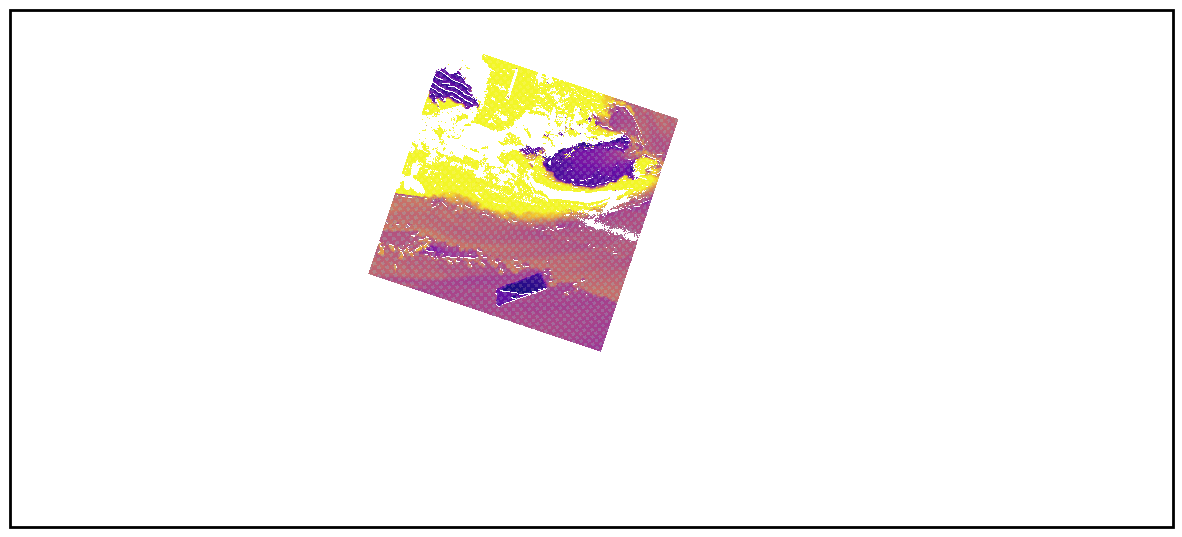

In [19]:
# Test plot of a few granules
to_plot = "wse"
label = "Elevation [m]"
vmin = 0
vmax = 200
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

# oslo = Colormap('crameri:oslo').to_matplotlib()
# ax.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
# cb = ax.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
#       vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',alpha=0.6,vmin=0,vmax=1100)

# plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
#                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

test_plot = [r for r in swot_rasters_adv[:1]]
print(len(test_plot))
for raster in test_plot:
    ds = xr.open_mfdataset(
        raster, combine="nested", concat_dim="num_lines", decode_times=False
    )
    wse = ds[to_plot].isel(num_lines=0)
    utm = ccrs.UTM(zone=ds.utm_zone_num, southern_hemisphere=True)
    x = ds.x.values
    y = ds.y.values

    X_adv = ds["x_adv"].isel(num_lines=0)
    Y_adv = ds["y_adv"].isel(num_lines=0)
    mesh_adv = ax.pcolormesh(
        X_adv,
        Y_adv,
        wse.values,
        transform=ps71_projection,
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=0.6,
    )

    X = ds["x_ps71"].isel(num_lines=0)
    Y = ds["y_ps71"].isel(num_lines=0)
    mesh = ax.pcolormesh(
        X,
        Y,
        wse.values,
        transform=ps71_projection,
        cmap="plasma",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=0.6,
    )


ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
fig.patch.set_alpha(0.0)
plt.draw()

In [68]:
# Pick primary raster to use as points for computation.
# Find points on any other raster closest to primary raster points, with max dist max_dist m

max_dist = 100  # Meters
primary_raster = swot_rasters_adv[0]


ds_primary = xr.open_mfdataset(
    primary_raster, combine="nested", concat_dim="num_lines", decode_times=False
)
primary_x = ds_primary["x_adv"].isel(num_lines=0).values
primary_y = ds_primary["y_adv"].isel(num_lines=0).values
primary_pts = np.column_stack([primary_x.ravel(), primary_y.ravel()])

mask = shapely.contains_xy(main_shapefile, primary_x, primary_y)

wse_primary = ds_primary["wse"].values
wse_primary_flat = wse_primary.ravel()

n_pts = primary_pts.shape[0]
wse_ts = np.full((n_pts, len(swot_rasters_adv)), np.nan)

time_ts = [ds_primary.time_granule_start]
wse_ts[:, 0] = wse_primary_flat
ny, nx = primary_x.shape

other_rasters = [r for r in swot_rasters_adv if r != primary_raster]
for t, raster in enumerate(other_rasters, start=1):
    print(f"Processing {raster.name} ({t}/{len(other_rasters)})")
    ds_secondary = xr.open_mfdataset(
        raster, combine="nested", concat_dim="num_lines", decode_times=False
    )
    secondary_x = ds_secondary["x_adv"].isel(num_lines=0).values
    secondary_y = ds_secondary["y_adv"].isel(num_lines=0).values
    wse = ds_secondary["wse"].values
    wse_flat = wse.ravel()
    secondary_points = np.column_stack([secondary_x.ravel(), secondary_y.ravel()])

    time_ts.append(ds_secondary.time_granule_start)

    # Make tree to query
    tree = cKDTree(secondary_points)
    dist, idx = tree.query(primary_pts, distance_upper_bound=max_dist)
    valid = dist != np.inf

    wse_ts[valid, t] = wse_flat[idx[valid]]


wse_ts = wse_ts.reshape(ny, nx, -1)  # (y, x, time)
wse_ts_masked = np.where(mask[:, :, None], wse_ts, np.nan)
ds_out = xr.Dataset(
    {"wse": (["y", "x", "time"], wse_ts_masked)},
    coords={
        "time": time_ts,
        "x": (["y", "x"], primary_x),
        "y": (["y", "x"], primary_y),
    },
)

Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_033_299_014F_20250529T131155_20250529T131216_PID0_02_adv.nc (1/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_034_299_014F_20250619T095658_20250619T095719_PID0_01_adv.nc (2/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_035_299_014F_20250710T064206_20250710T064227_PID0_01_adv.nc (3/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_036_299_014F_20250731T032710_20250731T032731_PID0_01_adv.nc (4/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_037_299_014F_20250821T001215_20250821T001236_PID0_01_adv.nc (5/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_038_299_014F_20250910T205718_20250910T205739_PID0_01_adv.nc (6/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_039_299_014F_20251001T174222_20251001T174244_PID0_01_adv.nc (7/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_040_299_014F_20251022T142728_20251022T142749_PID0_01_adv.nc (8/15)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_041_299_014F_20251112T1

(1808, 1808) (1808, 1808) (1808, 1808)
(1808, 1808) (1808, 1808) (1808, 1808)


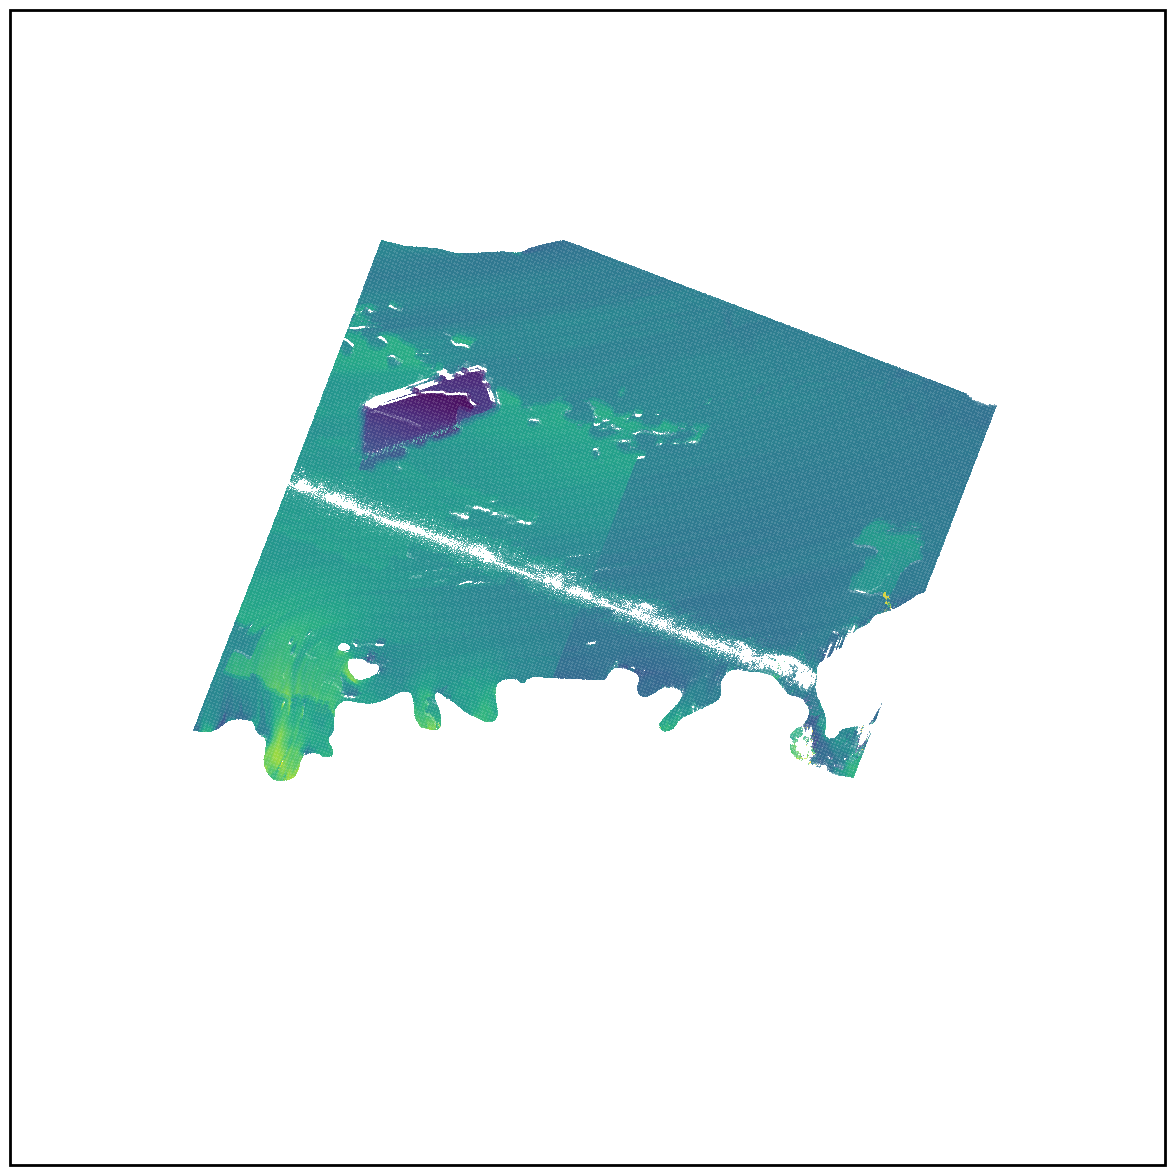

In [22]:
# Plot ds_out at each time step to verify
to_plot = "wse"
label = "Elevation [m]"
vmin = 0
vmax = 200
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

for i in range(2):
    wse = ds_out[to_plot][:, :, i]
    x = ds_out.x.values
    y = ds_out.y.values
    print(wse.shape, x.shape, y.shape)
    mesh_adv = ax.pcolormesh(
        x,
        y,
        wse.values,
        transform=ps71_projection,
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=0.6,
    )

In [69]:
# Mask bad data points as nan

# For each point, find median value and mask values that are more than 2 m from median
wse = ds_out.wse.values  # (y, x, time)
median = np.nanmedian(wse, axis=2)  # (y, x)
diff = np.abs(wse - median[:, :, None])  # (y, x, time)
wse_masked = np.where(diff > 2.0, np.nan, wse)  # (y, x, time)
ds_out["wse_masked"] = (("y", "x", "time"), wse_masked)

/tmp/ipykernel_123258/2946954738.py:5: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(wse, axis=2)             # (y, x)


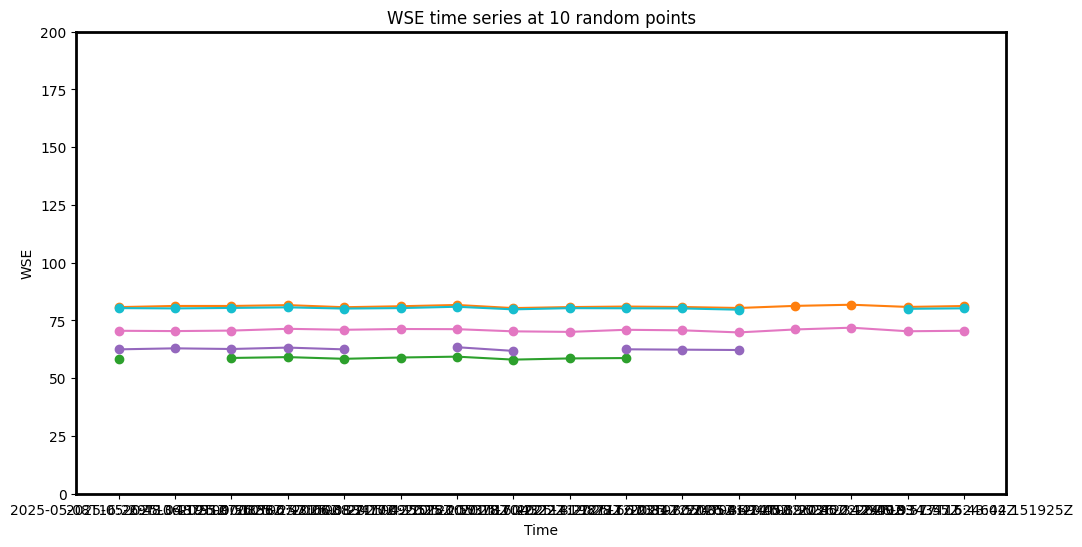

In [70]:
n_samples = 10
rng = np.random.default_rng()
y_idx = rng.integers(0, ny, size=n_samples)
x_idx = rng.integers(0, nx, size=n_samples)

plt.figure(figsize=(12, 6))

# <al

for y, x in zip(y_idx, x_idx):
    plt.plot(
        time_ts, ds_out["wse_masked"][y, x, :], marker="o", label=f"Point ({y}, {x})"
    )

plt.xlabel("Time")
plt.ylabel("WSE")
plt.title(f"WSE time series at {n_samples} random points")
plt.ylim(0, 200)
plt.show()

In [71]:
# Compute CATS at these points
model_loc = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background"
model = "CATS2008-v2023"

# Ravel and reshape after tide calculation
x_ravel = ds_out.x.values.ravel()
y_ravel = ds_out.y.values.ravel()
lons, lats = transforms.xy2ll(x_ravel, y_ravel)
tide_times = [
    datetime.strptime(time, "%Y-%m-%dT%H:%M:%S.%fZ") for time in ds_out.time.values
]

In [72]:
model = pyTMD.io.model(model_loc, format="netcdf").elevation(model)
constituents_pyTMD = pyTMD.io.OTIS.read_constants(
    model.grid_file,
    model.model_file,
    model.projection,
    type=model.type,
    grid=model.format,
)
c = constituents_pyTMD.fields

In [73]:
amp_pyTMD, ph_pyTMD, D = pyTMD.io.OTIS.interpolate_constants(
    np.atleast_1d(lons),
    np.atleast_1d(lats),
    constituents_pyTMD,
    type=model.type,
    method="spline",
    extrapolate=True,
)

In [74]:
amp_pyTMD = [ap[:8] for ap in amp_pyTMD]
ph_pyTMD = [p[:8] for p in ph_pyTMD]

In [75]:
# Reshape back to grid and add to ds_out
amp_pyTMD_grid = np.array(amp_pyTMD).reshape(ny, nx, -1)
ph_pyTMD_grid = np.array(ph_pyTMD).reshape(ny, nx, -1)
amp_pyTMD_grid_masked = np.where(mask[:, :, None], amp_pyTMD_grid, np.nan)
ph_pyTMD_grid_masked = np.where(mask[:, :, None], ph_pyTMD_grid, np.nan)
ds_out["amp_pyTMD"] = (("y", "x", "constituent"), amp_pyTMD_grid_masked[:, :, :8])
ds_out["ph_pyTMD"] = (("y", "x", "constituent"), ph_pyTMD_grid_masked[:, :, :8])

(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)


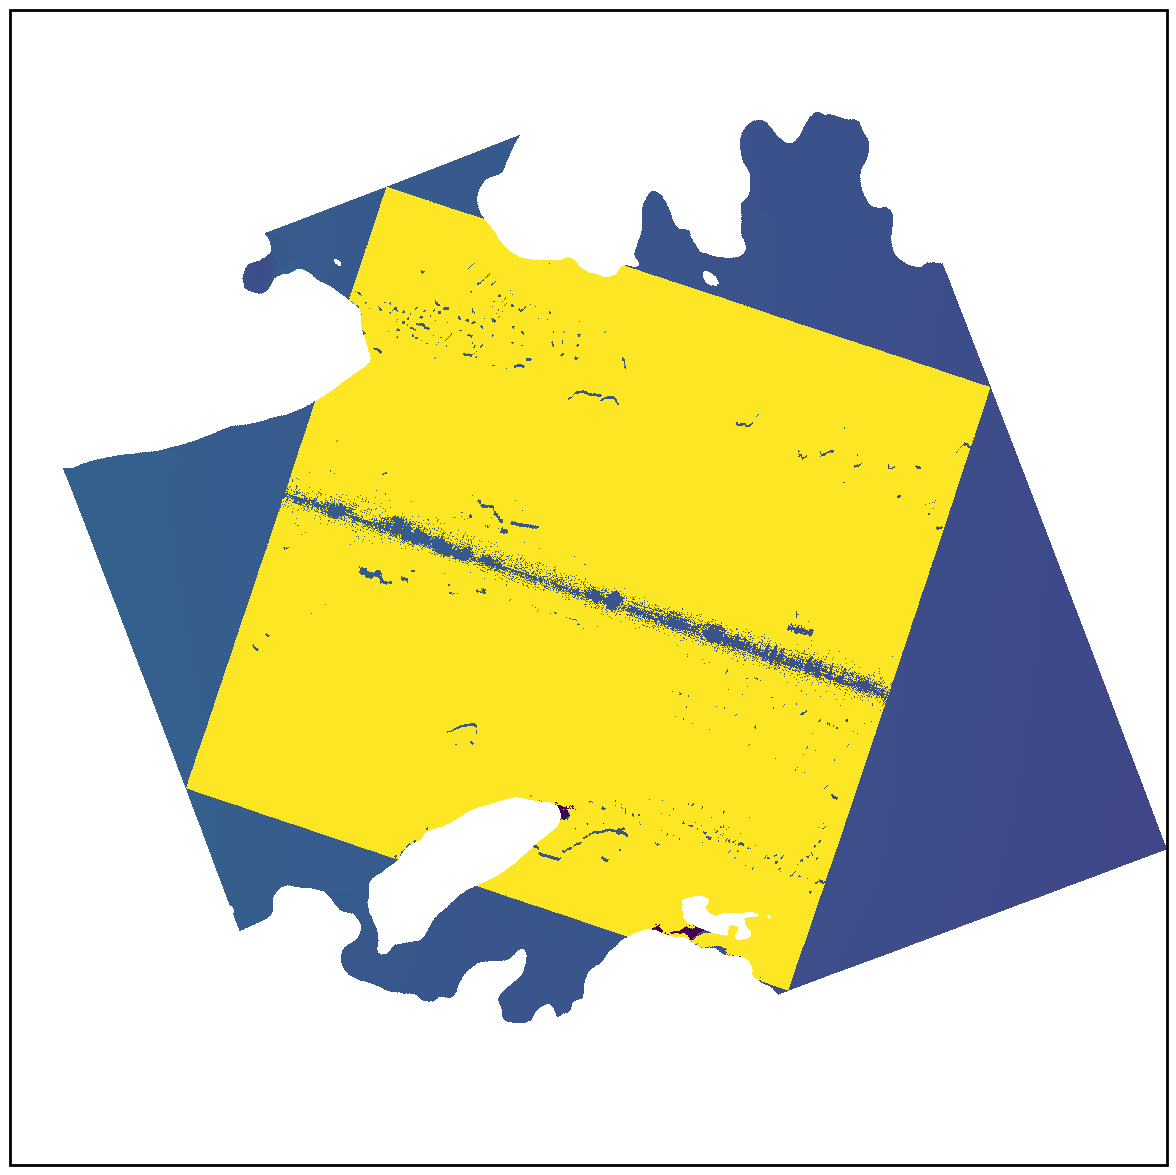

In [76]:
# Plot CATS at a few time steps to verify
to_plot = "amp_pyTMD"
label = "Elevation [m]"
vmin = 0
vmax = 1
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

wse = ds_out[to_plot][:, :, 1]
# wse = ds_out['wse'][:,:,1]
x = ds_out.x.values
y = ds_out.y.values
print(wse.shape, x.shape, y.shape)
mesh_adv = ax.pcolormesh(
    x,
    y,
    wse.values,
    transform=ps71_projection,
    cmap="viridis",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    alpha=1,
)

wse = ds_out[to_plot][:, :, 1]
wse = ds_out["wse"][:, :, 1]
x = ds_out.x.values
y = ds_out.y.values
print(wse.shape, x.shape, y.shape)
mesh_adv = ax.pcolormesh(
    x,
    y,
    wse.values,
    transform=ps71_projection,
    cmap="viridis",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    alpha=1,
)

In [77]:
# Harmonic analysis at each point
# Try sinusoid fit

# Tidal constituents [hr]
HR_IN_DAY = 24
SEC_IN_HR = 3600

M2 = 12.4206012
S2 = 12
N2 = 12.65834751
K2 = 11.96723606

K1 = 23.9344721
O1 = 25.81933871
P1 = 24.06588766
Q1 = 26.868350

constituents = {
    "M2": M2,
    "S2": S2,
    "N2": N2,
    "K2": K2,
    "K1": K1,
    "O1": O1,
    "P1": P1,
    "Q1": Q1,
}


def tide_model(t, periods, parameters):
    """
    Generate the tide from synthetic data.

    Parameters
    ----------
    t : List
        List of sampling times in hours
    periods : dict
        Dictionary of tidal constituent periods in hours
    parameters : list
        List in form [A1, A2, ... , phi_1, phi_2, ...]
        where A is the amplitude in m and phi is the phase shift in radians

    Returns
    -------
    modeled : list
        Tides at time t as estimated by the model
    """
    assert len(parameters) == 2 * len(
        periods
    ), "Parameters must be twice the number of periods"

    model = np.zeros_like(t, dtype=float)
    n = len(periods)
    for i in range(n):
        A = parameters[i]
        phi = parameters[i + n]
        model += A * np.cos(2 * np.pi * t / periods[i] - phi)
    return model


def residuals(parameters, t, data, periods):
    """
    Residual function for scipy's least_squares
    Scipy does the squaring for us.
    """
    return tide_model(t, periods, parameters) - data


periods = [constituents[c] for c in constituents]

initial_guess = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
amp_grid = np.full((ny, nx, 8), np.nan)
ph_grid = np.full((ny, nx, 8), np.nan)

times = np.array(ds_out.time.values, dtype="datetime64[ns]")
t_hours = (times - times[0]) / np.timedelta64(1, "h")

periods = np.array([M2, S2, N2, K2, K1, O1, P1, Q1])
omega = 2 * np.pi / periods

# Design matrix
t_col = t_hours[:, None]  # (time, 1)

X = np.hstack([np.cos(t_col * omega), np.sin(t_col * omega)])

# This has lots of nans, need to mask
# Each row now has different shape...
wse = ds_out.wse.values  # (y, x, time)

ny, nx, nt = wse.shape

# reshape to (space, time)
Y = wse.reshape(ny * nx, nt).T  # (time, n_points)
beta, *_ = np.linalg.lstsq(X, Y, rcond=None)

/tmp/ipykernel_123258/550418884.py:73: UserWarning: no explicit representation of timezones available for np.datetime64
  times = np.array(ds_out.time.values, dtype='datetime64[ns]')


: 

In [ ]:
np.unique(ds_out["amp_fit"][:, :, 0])

array([ 10.09901054,  10.34995052,  10.36813327, ..., 192.31974737,
       197.5567585 ,          nan], shape=(943159,))

In [47]:
A = beta[:8, :]
B = beta[8:, :]

amp = np.sqrt(A**2 + B**2)
phase = np.arctan2(-B, A)  # radians
phase_deg = np.degrees(phase) % 360

amp_grid = amp.T.reshape(ny, nx, 8)
ph_grid = phase_deg.T.reshape(ny, nx, 8)

ds_out["amp_fit"] = (("y", "x", "constituent"), amp_grid)
ds_out["ph_fit"] = (("y", "x", "constituent"), ph_grid)

In [55]:
np.unique(amp)

array([  9.99860552,  10.00593192,  10.04273029, ..., 143.19170876,
       183.66750214,          nan], shape=(943159,))

In [62]:
# Plot Fitted Amp
to_plot = "amp_fit"
label = "Elevation [m]"
vmin = 0
vmax = 150
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

amp = ds_out[to_plot][:, :, 0]
x = ds_out.x.values
y = ds_out.y.values
print(amp.shape, x.shape, y.shape)
mesh_adv = ax.pcolormesh(
    x,
    y,
    amp.values,
    transform=ps71_projection,
    cmap="viridis",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    alpha=1,
)

(1808, 1808) (1808, 1808) (1808, 1808)


: 